# LIME — a step-by-step walkthrough (breast cancer, 100% real data)

569 real patients, a real 30-feature RandomForest, and a real decision
boundary (a ceteris-paribus slice along the 2 chosen axes). First the
logic/formula of the method; then the 6 steps of the mechanism, on a case
where the explanation IS reliable; finally, a case where it is NOT — to
make clear that "reliable" is not automatic: it is something you measure.

All 6 mechanism plots use the SAME window (same axis scale) — so you can
compare one step against another directly, without re-reading the axis
numbers every time.

## Setup

In [1]:
%pip install -q lime scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
BLUE = "#315B86"        # benign
TERRACOTTA = "#C96F3F"  # malignant
DARK = "#252525"
GRAY = "#A8A8A8"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 140})

## What LIME is

Many models — like the 300-tree RandomForest we use here — are black
boxes: they predict well, but you cannot read the "why" directly off their
parameters. LIME (*Local Interpretable Model-agnostic Explanations*,
[Ribeiro, Singh & Guestrin, 2016](https://christophm.github.io/interpretable-ml-book/lime.html))
does not try to explain the whole model — only its behavior **near one
specific prediction**, by approximating it there with a simple model (a
straight line).

The idea in one sentence: generate synthetic neighbors around the point,
ask the real model what it thinks of each one, and fit a regression to
those answers — giving more weight to the neighbors closest to the
original point.

## What we are optimizing

$$\xi(x) = \operatorname*{arg\,min}_{g \,\in\, G} \;\; \mathcal{L}(f, g, \pi_x) \, + \, \Omega(g)$$

| symbol | what it is | here, in this walkthrough |
|---|---|---|
| $f$ | the real model (black box) | the 300-tree RandomForest |
| $g$ | the local interpretable model | a Ridge regression |
| $\pi_x$ | proximity weight of each neighbor $z$ to $x$ | $\pi_x(z) = \sqrt{\exp(-d(x,z)^2/\nu^2)}$ |
| $\mathcal{L}$ | how much $g$ errs at reproducing $f$ in the neighborhood | squared error, weighted by $\pi_x$ |
| $\Omega(g)$ | complexity penalty on $g$ | only the 8 highest-weight features enter |

In the next 6 steps, each piece of this formula gets its own plot. At the
end, we discuss what Molnar's book calls **local fidelity**: how much $g$
actually resembles $f$ — and why that is not always high.

## The model and the instance

300 trees: this did not come from a grid search / cross-validation in this
project — it is a common manual choice (sklearn's default is 100; more
trees reduce the variance of the probabilities with diminishing returns;
300 is "comfortably more than enough" for 30 features / ~570 rows, without
being costly).

The patient (#48) and the 2 axes (`worst area`, `worst perimeter`) come
from a search over the 143 test patients: among those the model gets right
AND whose 2 highest-weight features in the official explanation make the
real boundary and the local-fit line fall inside the data range, we picked
the one with the BEST fidelity of the line right at the point itself (not
just in the surroundings). A finding from that search: none of the 143 has
everything perfect at once — high confidence and perfect point-level
fidelity rarely go together (more on this in the closing section).

The window of every plot below is fixed: ±2.5σ around the patient on each
axis (clipped to the real data range) — large enough to show the
neighborhood (2.4σ) with room to spare, small enough not to lose the
boundary detail among 569 scattered points.

In [3]:
data = load_breast_cancer()
X_all, y_all = data.data, data.target
feature_names = list(data.feature_names)
class_names = list(data.target_names)  # ['malignant', 'benign']
feat_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE, stratify=y_all
)
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, model.predict(X_test))
test_auc = roc_auc_score(y_test, proba_test)

instance_idx = 48  # found by the search — see text above
row = X_test[instance_idx]
row_proba = proba_test[instance_idx]
predicted = class_names[int(row_proba >= 0.5)]
true_label = class_names[y_test[instance_idx]]

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
row_scaled = (row - train_mean) / train_std
kernel_width = 0.75 * np.sqrt(len(feature_names))

axis_x_name, axis_y_name = "worst area", "worst perimeter"
ix, iy = feat_idx[axis_x_name], feat_idx[axis_y_name]

print(f"patient #{instance_idx}: P(benign)={row_proba:.3f}  predicted={predicted}  true={true_label}")
print(f"test accuracy={test_acc:.1%}  ROC-AUC={test_auc:.3f}")
print(f"chosen axes: {axis_x_name}={row[ix]:.1f}  |  {axis_y_name}={row[iy]:.1f}")


def boundary_slice(clf, base_row, grid_x, grid_y):
    """The REAL decision boundary of the 30-feature model, sliced along the
    plane of the 2 chosen axes — the other 28 features stay fixed at THIS
    patient's values (ceteris paribus)."""
    GX, GY = np.meshgrid(grid_x, grid_y)
    points = np.tile(base_row, (GX.size, 1))
    points[:, ix] = GX.ravel()
    points[:, iy] = GY.ravel()
    proba = clf.predict_proba(points)[:, 1]
    return GX, GY, proba.reshape(GX.shape)


# ONE window only, used in EVERY plot below (including the final combined
# figure): ±2.5σ around the patient, clipped to the real data range —
# without this, the boundary/line detail is too small to read across the
# dataset's full span.
WINDOW = 2.5
lo_x, hi_x = X_all[:, ix].min(), X_all[:, ix].max()
lo_y, hi_y = X_all[:, iy].min(), X_all[:, iy].max()
grid_x = np.linspace(max(lo_x, row[ix] - WINDOW * train_std[ix]), min(hi_x, row[ix] + WINDOW * train_std[ix]), 220)
grid_y = np.linspace(max(lo_y, row[iy] - WINDOW * train_std[iy]), min(hi_y, row[iy] + WINDOW * train_std[iy]), 200)
GX, GY, PROB_SLICE = boundary_slice(model, row, grid_x, grid_y)
print(f"real boundary crosses this window: {PROB_SLICE.min() < 0.5 < PROB_SLICE.max()}")

patient #48: P(benign)=0.253  predicted=malignant  true=malignant
test accuracy=95.1%  ROC-AUC=0.993
chosen axes: worst area=1218.0  |  worst perimeter=128.2
real boundary crosses this window: True


## Drawing tools

The same layers, reused in every step AND in the final combined figure —
only the combination of layers changes per plot. The window
(`grid_x`/`grid_y`) is always the same.

In [4]:
FIG_DIR = "figures_generated"  # regenerated on every run; canonical copies live in ../figures
os.makedirs(FIG_DIR, exist_ok=True)


def new_figure(title, figsize=(8.5, 6.6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    return fig, ax


def draw_base(ax):
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=24, color=BLUE, alpha=0.5,
               linewidth=0, label="benign (true label)")
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=24, color=TERRACOTTA, alpha=0.5,
               linewidth=0, label="malignant (true label)")
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[DARK], linewidths=1.8, linestyles="--")
    ax.plot([], [], color=DARK, linewidth=1.8, linestyle="--", label="true boundary (P=0.5)")
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=11)
    ax.set_ylabel(axis_y_name, fontsize=11)
    ax.tick_params(labelsize=9.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)


def draw_patient(ax, annotate=False):
    ax.scatter(row[ix], row[iy], s=200, marker="x", color=DARK, linewidths=3,
               zorder=20, label=f"patient #{instance_idx}")
    if annotate:
        ax.annotate(f"P(benign) = {row_proba:.3f}", (row[ix], row[iy]),
                    xytext=(12, 14), textcoords="offset points", fontsize=10,
                    color=DARK, fontweight="bold")


def draw_neighborhood(ax):
    ellipse = Ellipse((row[ix], row[iy]), width=2.4 * train_std[ix], height=2.4 * train_std[iy],
                      fill=False, color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85)
    ax.add_patch(ellipse)
    ax.plot([], [], color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85,
            label="local neighborhood (2.4σ)")


def draw_neighbors(ax, Z, colors=GRAY, sizes=24, alphas=0.55, label=None):
    ax.scatter(Z[:, ix], Z[:, iy], s=sizes, color=colors, alpha=alphas, linewidth=0, label=label)


def local_line(exp, base_row, grid_x, grid_y):
    """The P=0.5 line of the official local fit. `local_exp`/`intercept` are
    coefficients in STANDARDIZED space — the package fits on standardized
    data, not raw units (see lime_internals.ipynb for the line-by-line
    validation against the source code); so we convert base_row and the grid
    to standardized space before applying the coefficients, and only convert
    back to real units at the end, so it can be drawn."""
    coef_map = dict(exp.local_exp[1])
    base_scaled = (base_row - train_mean) / train_std
    others = sum(w * base_scaled[j] for j, w in coef_map.items() if j not in (ix, iy))
    grid_x_scaled = (grid_x - train_mean[ix]) / train_std[ix]
    y_scaled = (0.5 - exp.intercept[1] - others - coef_map[ix] * grid_x_scaled) / coef_map[iy]
    y_line = y_scaled * train_std[iy] + train_mean[iy]
    inside = (y_line >= grid_y.min()) & (y_line <= grid_y.max())
    return y_line, inside


def draw_line(ax, exp, grid_x, grid_y):
    coef_map = dict(exp.local_exp[1])
    if ix not in coef_map or iy not in coef_map or abs(coef_map[iy]) < 1e-9:
        return False
    y_line, inside = local_line(exp, row, grid_x, grid_y)
    if inside.any():
        ax.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=3,
                 label="local fit (Ridge, P=0.5)")
        return True
    return False


def add_legend(ax):
    ax.legend(loc="upper left", fontsize=9, frameon=True, framealpha=0.92, edgecolor="none")


def save_figure(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=200, bbox_inches="tight")

## Step 1 — the black-box model

A classifier that returns P(benign) for any patient — we do not look
inside it, we only call `predict_proba()`. The dashed line is the REAL
decision boundary of the RandomForest — it is not a smooth diagonal
because a RandomForest splits one feature at a time internally, so even
the average of 300 trees tends to produce "elbow"-shaped boundaries.

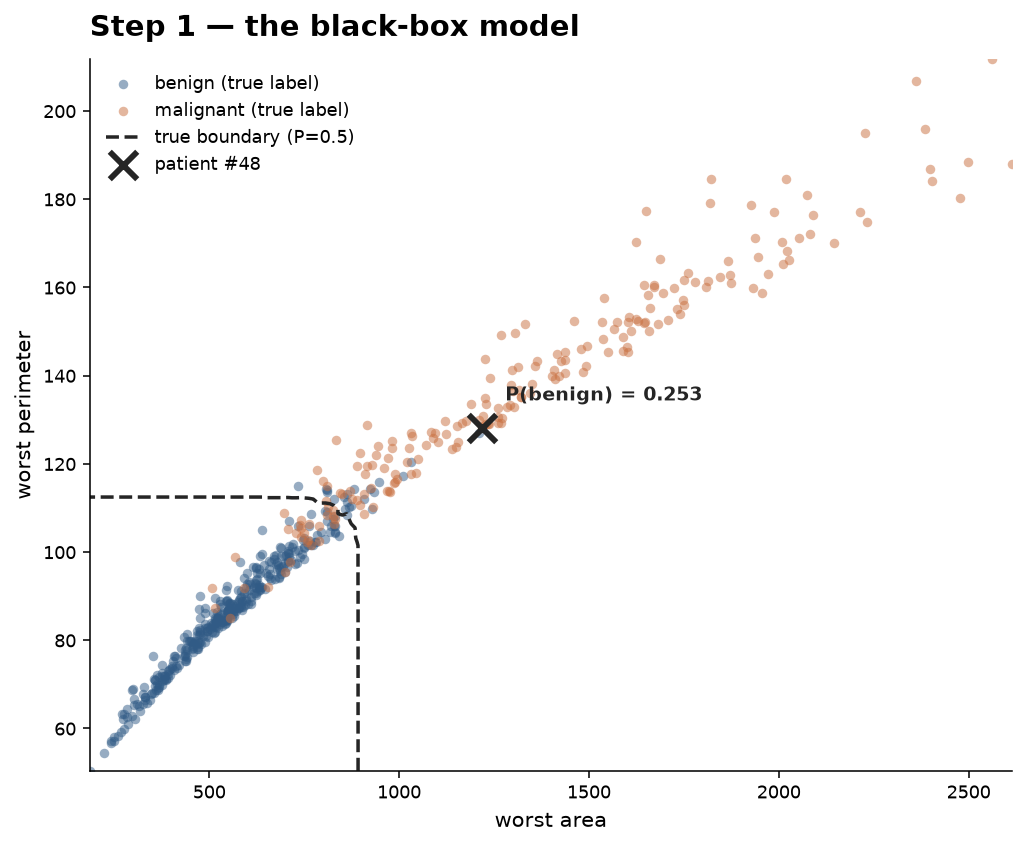

In [5]:
fig, ax = new_figure("Step 1 — the black-box model")
draw_base(ax)
draw_patient(ax, annotate=True)
add_legend(ax)
save_figure(fig, "lime_step_1")
plt.show()

## Step 2 — the local neighborhood

LIME does not explain the whole model, only its behavior near this
patient. The ellipse is the 2D projection of the neighborhood (each axis's
σ in the training data) — wider along the axis with more natural
variation, which is why it is not a circle.

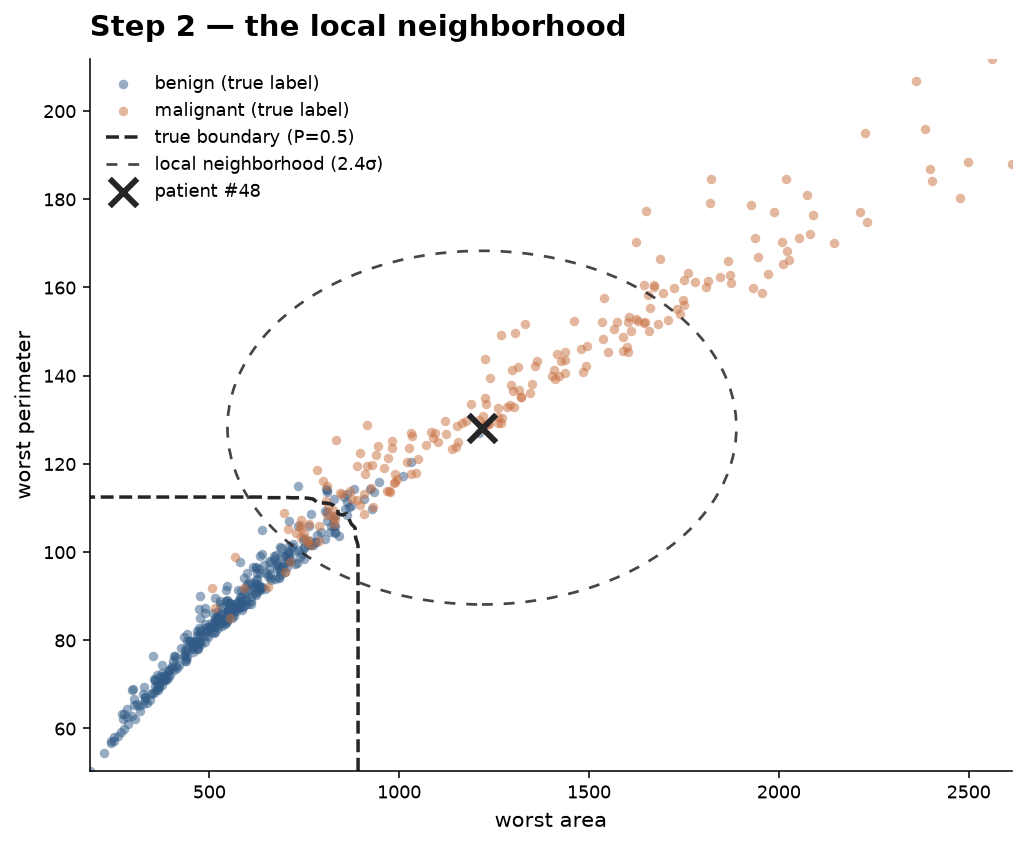

In [6]:
fig, ax = new_figure("Step 2 — the local neighborhood")
draw_base(ax)
draw_neighborhood(ax)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_2")
plt.show()

## Step 3 — perturbation: generating synthetic neighbors

$$z = \mu + \sigma \cdot \mathcal{N}(0,1)$$

— across all 30 features at once, each with its own training mean/σ. Here
we plot only the projection onto the 2 chosen axes; the real formula
(5,000 neighbors) is checked line by line against the package source code
in `lime_internals.ipynb`.

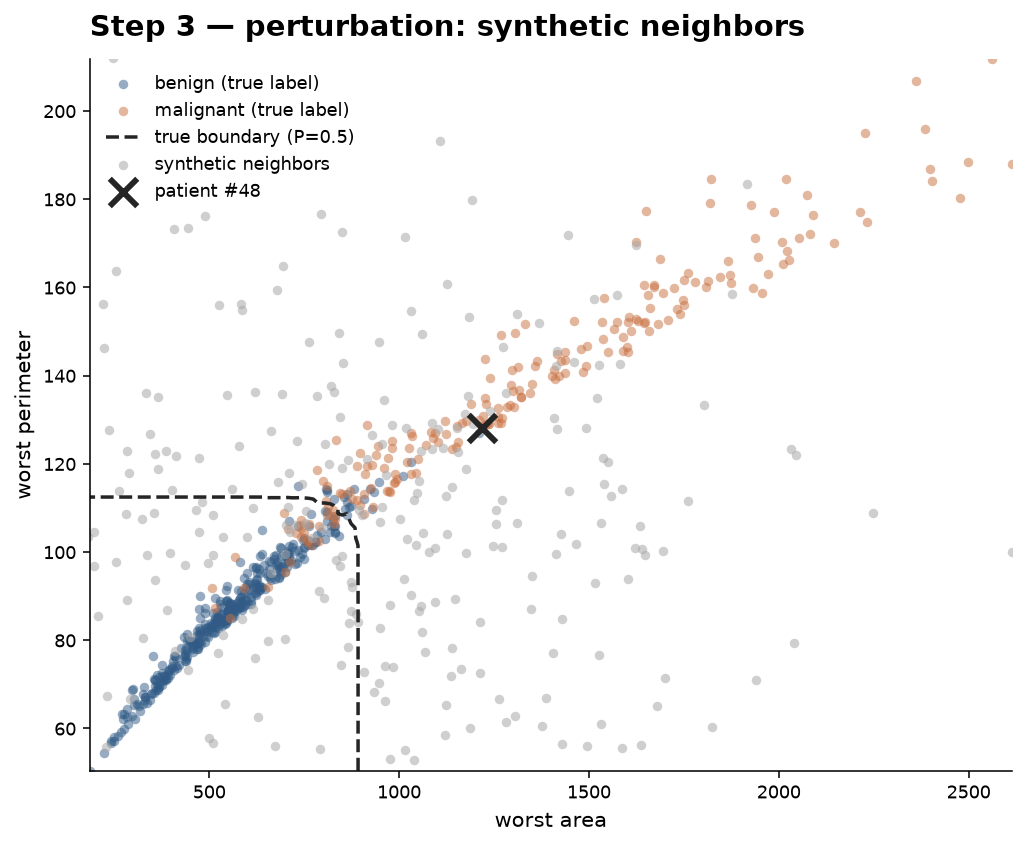

In [7]:
rng_vis = np.random.RandomState(RANDOM_STATE)
N_VIS = 300
Z_vis = train_mean + train_std * rng_vis.normal(0, 1, size=(N_VIS, len(feature_names)))

fig, ax = new_figure("Step 3 — perturbation: synthetic neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=GRAY, label="synthetic neighbors")
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_3")
plt.show()

## Step 4 — what the model thinks of each synthetic neighbor

The only moment the REAL model is called: `predict_proba` on each
synthetic neighbor — to the model, each one is just another row of 30
numbers.

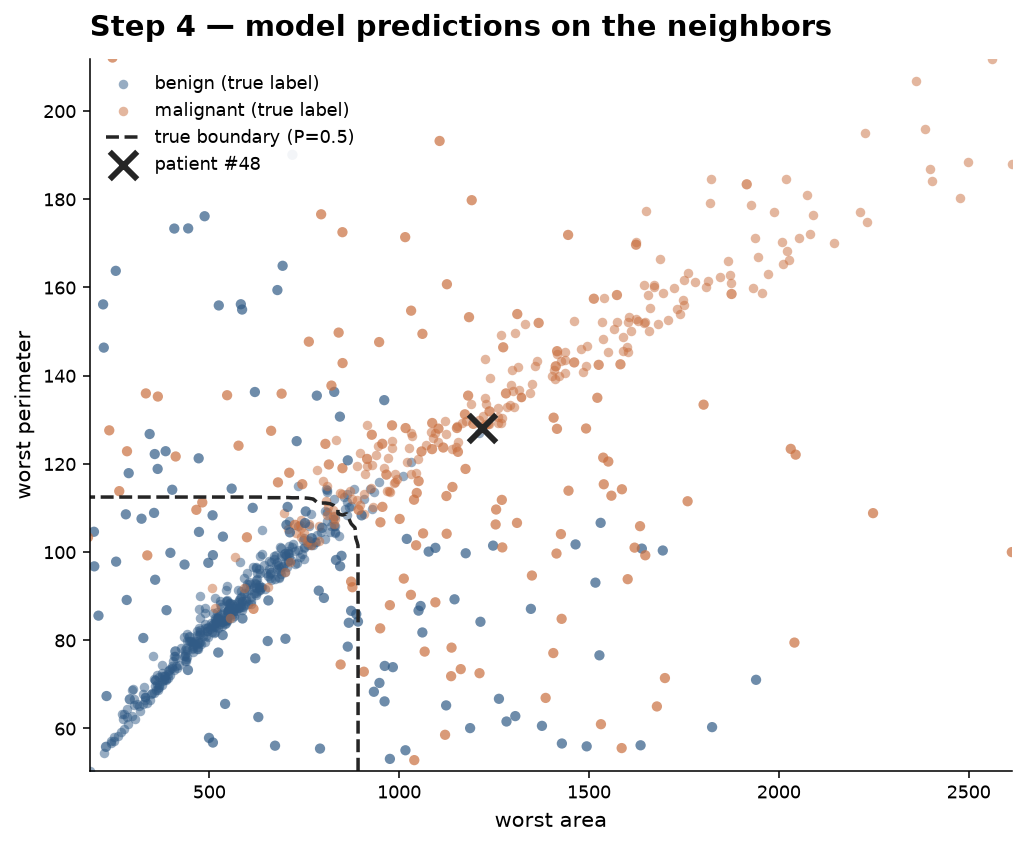

In [8]:
Z_vis_proba = model.predict_proba(Z_vis)[:, 1]
neighbor_colors = np.where(Z_vis_proba >= 0.5, BLUE, TERRACOTTA)

fig, ax = new_figure("Step 4 — model predictions on the neighbors")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=28, alphas=0.7)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_4")
plt.show()

## Step 5 — proximity weighting

The dots become large/opaque here for the first time because this is where
each neighbor's weight $\pi_x$ is computed — in steps 3-4 they all had the
same size. Important point: the distance is computed on the 30
**standardized** features, not just the 2 axes of the plot — so a point
that looks far from the patient IN THIS DRAWING can have a high weight
(big dot) if it resembles her on the other 28 features, and vice versa.
The weight uses the package's own kernel:

$$\pi_x(z) = \sqrt{\exp\!\left(-\dfrac{d(x,z)^2}{\nu^2}\right)}$$

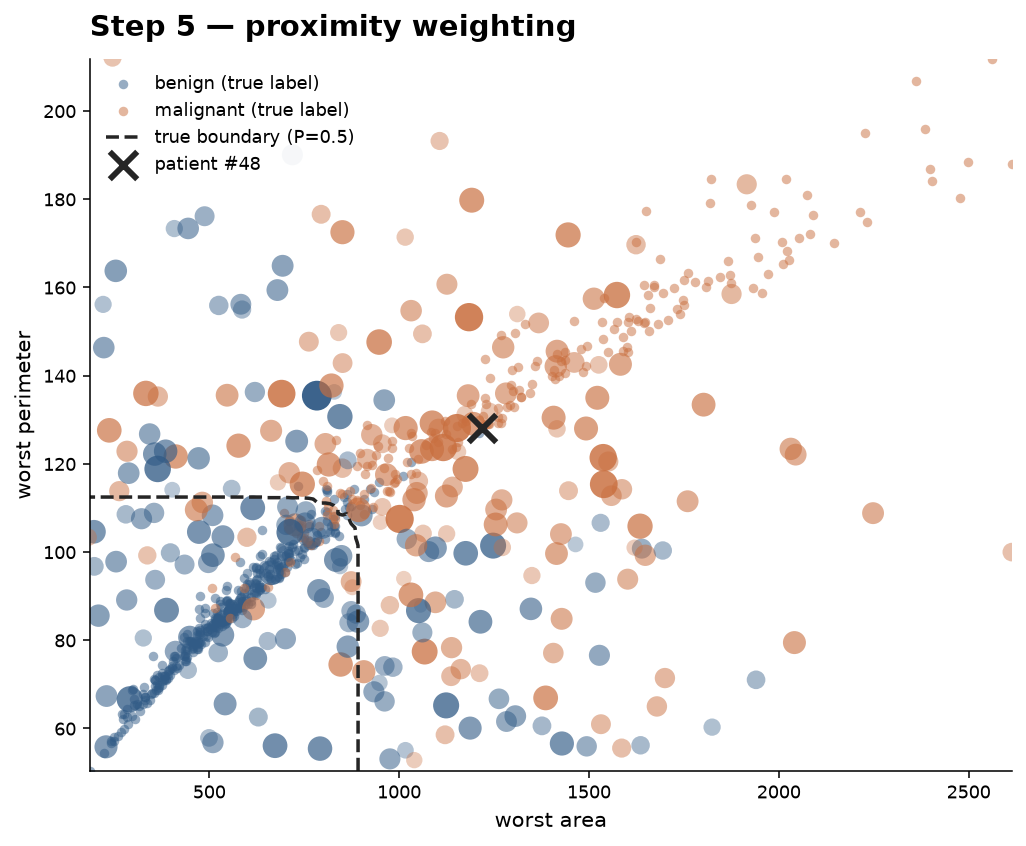

In [9]:
Z_vis_scaled = (Z_vis - train_mean) / train_std
dist_vis = np.linalg.norm(Z_vis_scaled - row_scaled, axis=1)
weight_vis = np.sqrt(np.exp(-(dist_vis ** 2) / (kernel_width ** 2)))
neighbor_sizes = 15 + 220 * (weight_vis / weight_vis.max())
neighbor_alphas = np.clip(0.15 + 0.8 * (weight_vis / weight_vis.max()), 0, 1)

fig, ax = new_figure("Step 5 — proximity weighting")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas)
draw_patient(ax)
add_legend(ax)
save_figure(fig, "lime_step_5")
plt.show()

## Step 6 — the local fit and its interpretation

The black line is a model — and it is LINEAR: a Ridge regression (linear
regression with L2 penalty, `alpha=1`, the package default), fitted on the
8 highest-weight features (out of 30, via the `highest_weights`
selection), weighted by the $\pi_x$ from step 5. The line in the plot is
that weighted sum solved for P=0.5 and projected onto the 2 chosen axes.
A single official call (`explain_instance`, 5,000 samples): the numbers
below are exactly what it returns — no parallel refit trying to imitate
it.

**Two things that are not the same thing**: the PREDICTION (the P(benign)
printed above) always comes from the real RandomForest, not from the line
— that does not change with the R². The R² measures how well the line
matches the real model OVER THE WHOLE NEIGHBORHOOD, not just at the
patient's point. After the figure, we check the two separately.

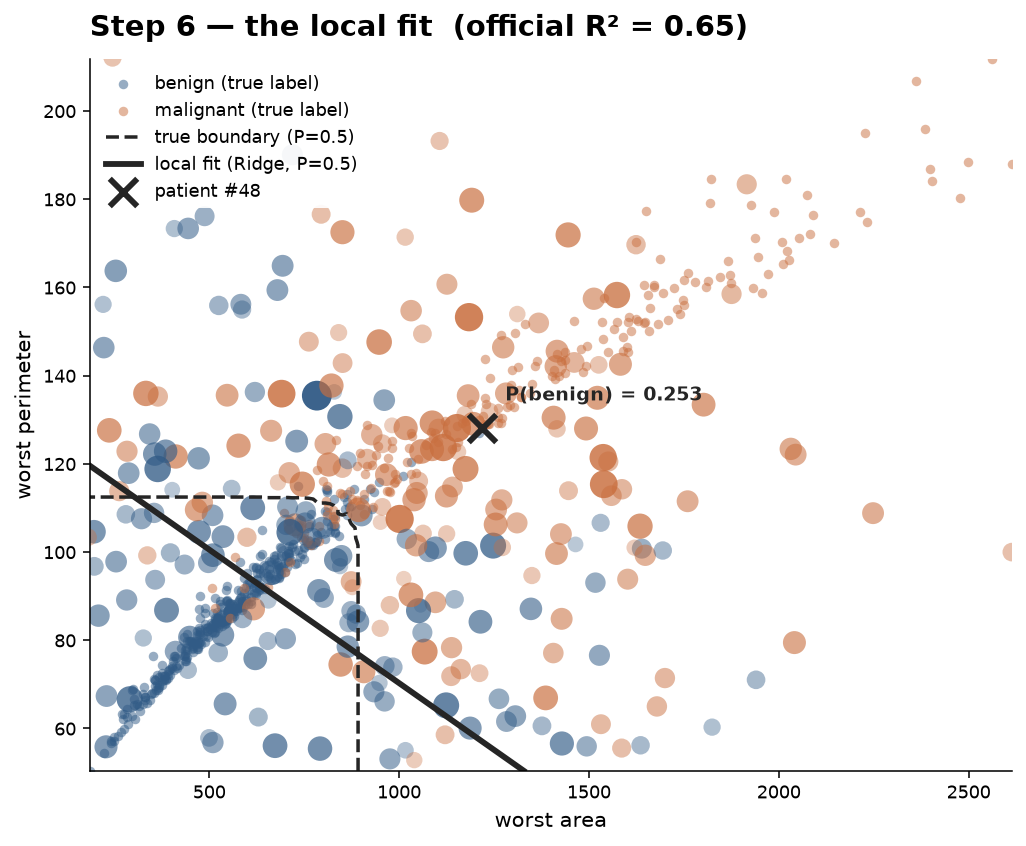

R² (local fidelity, official): 0.652
local-fit line visible in the plot: True
highest-weight feature: worst area (-0.0721, +0.6 standard deviations for this patient)


In [10]:
explainer = LimeTabularExplainer(
    X_train, feature_names=feature_names, class_names=class_names,
    discretize_continuous=False, random_state=RANDOM_STATE,
)
exp = explainer.explain_instance(
    row, model.predict_proba, num_features=8, num_samples=5000, labels=(1,)
)
r2 = exp.score
weights_map = {feature_names[f]: w for f, w in exp.local_exp[1]}
top_feat = max(weights_map, key=lambda f: abs(weights_map[f]))
i_top = feat_idx[top_feat]

fig, ax = new_figure(f"Step 6 — the local fit  (official R² = {r2:.2f})")
draw_base(ax)
draw_neighbors(ax, Z_vis, colors=neighbor_colors, sizes=neighbor_sizes, alphas=neighbor_alphas)
line_visible = draw_line(ax, exp, grid_x, grid_y)
draw_patient(ax, annotate=True)
add_legend(ax)
save_figure(fig, "lime_step_6")
plt.show()

print(f"R² (local fidelity, official): {r2:.3f}")
print(f"local-fit line visible in the plot: {line_visible}")
print(f"highest-weight feature: {top_feat} ({weights_map[top_feat]:+.4f}, "
      f"{(row[i_top]-train_mean[i_top])/train_std[i_top]:+.1f} standard deviations for this patient)")

### How much should we trust this line?

Right on top of the patient, the line is reasonably faithful to the real
model (that is what LIME optimizes for — the original point carries the
highest possible weight), and the R² over the whole neighborhood is also
good (0.65, the best balance we found across the 143 test patients — see
the text above). This is neither free nor guaranteed: in the closing
section, we show a case where none of it holds.

In [11]:
point_pred = exp.local_pred[0]
print(f"P(benign) from the real model, at the patient:      {row_proba:.4f}")
print(f"P(benign) predicted by the line, at the patient:    {point_pred:.4f}")
print(f"difference right at the patient:                    {abs(row_proba - point_pred):.4f}")
print(f"R² over the whole neighborhood (5,000 weighted):    {r2:.4f}")

P(benign) from the real model, at the patient:      0.2533
P(benign) predicted by the line, at the patient:    0.3483
difference right at the patient:                    0.0950
R² over the whole neighborhood (5,000 weighted):    0.6515


## Final figure — the 6 steps, side by side

The same layers from each step, assembled into a single panel, all with
the SAME window as steps 1-6.

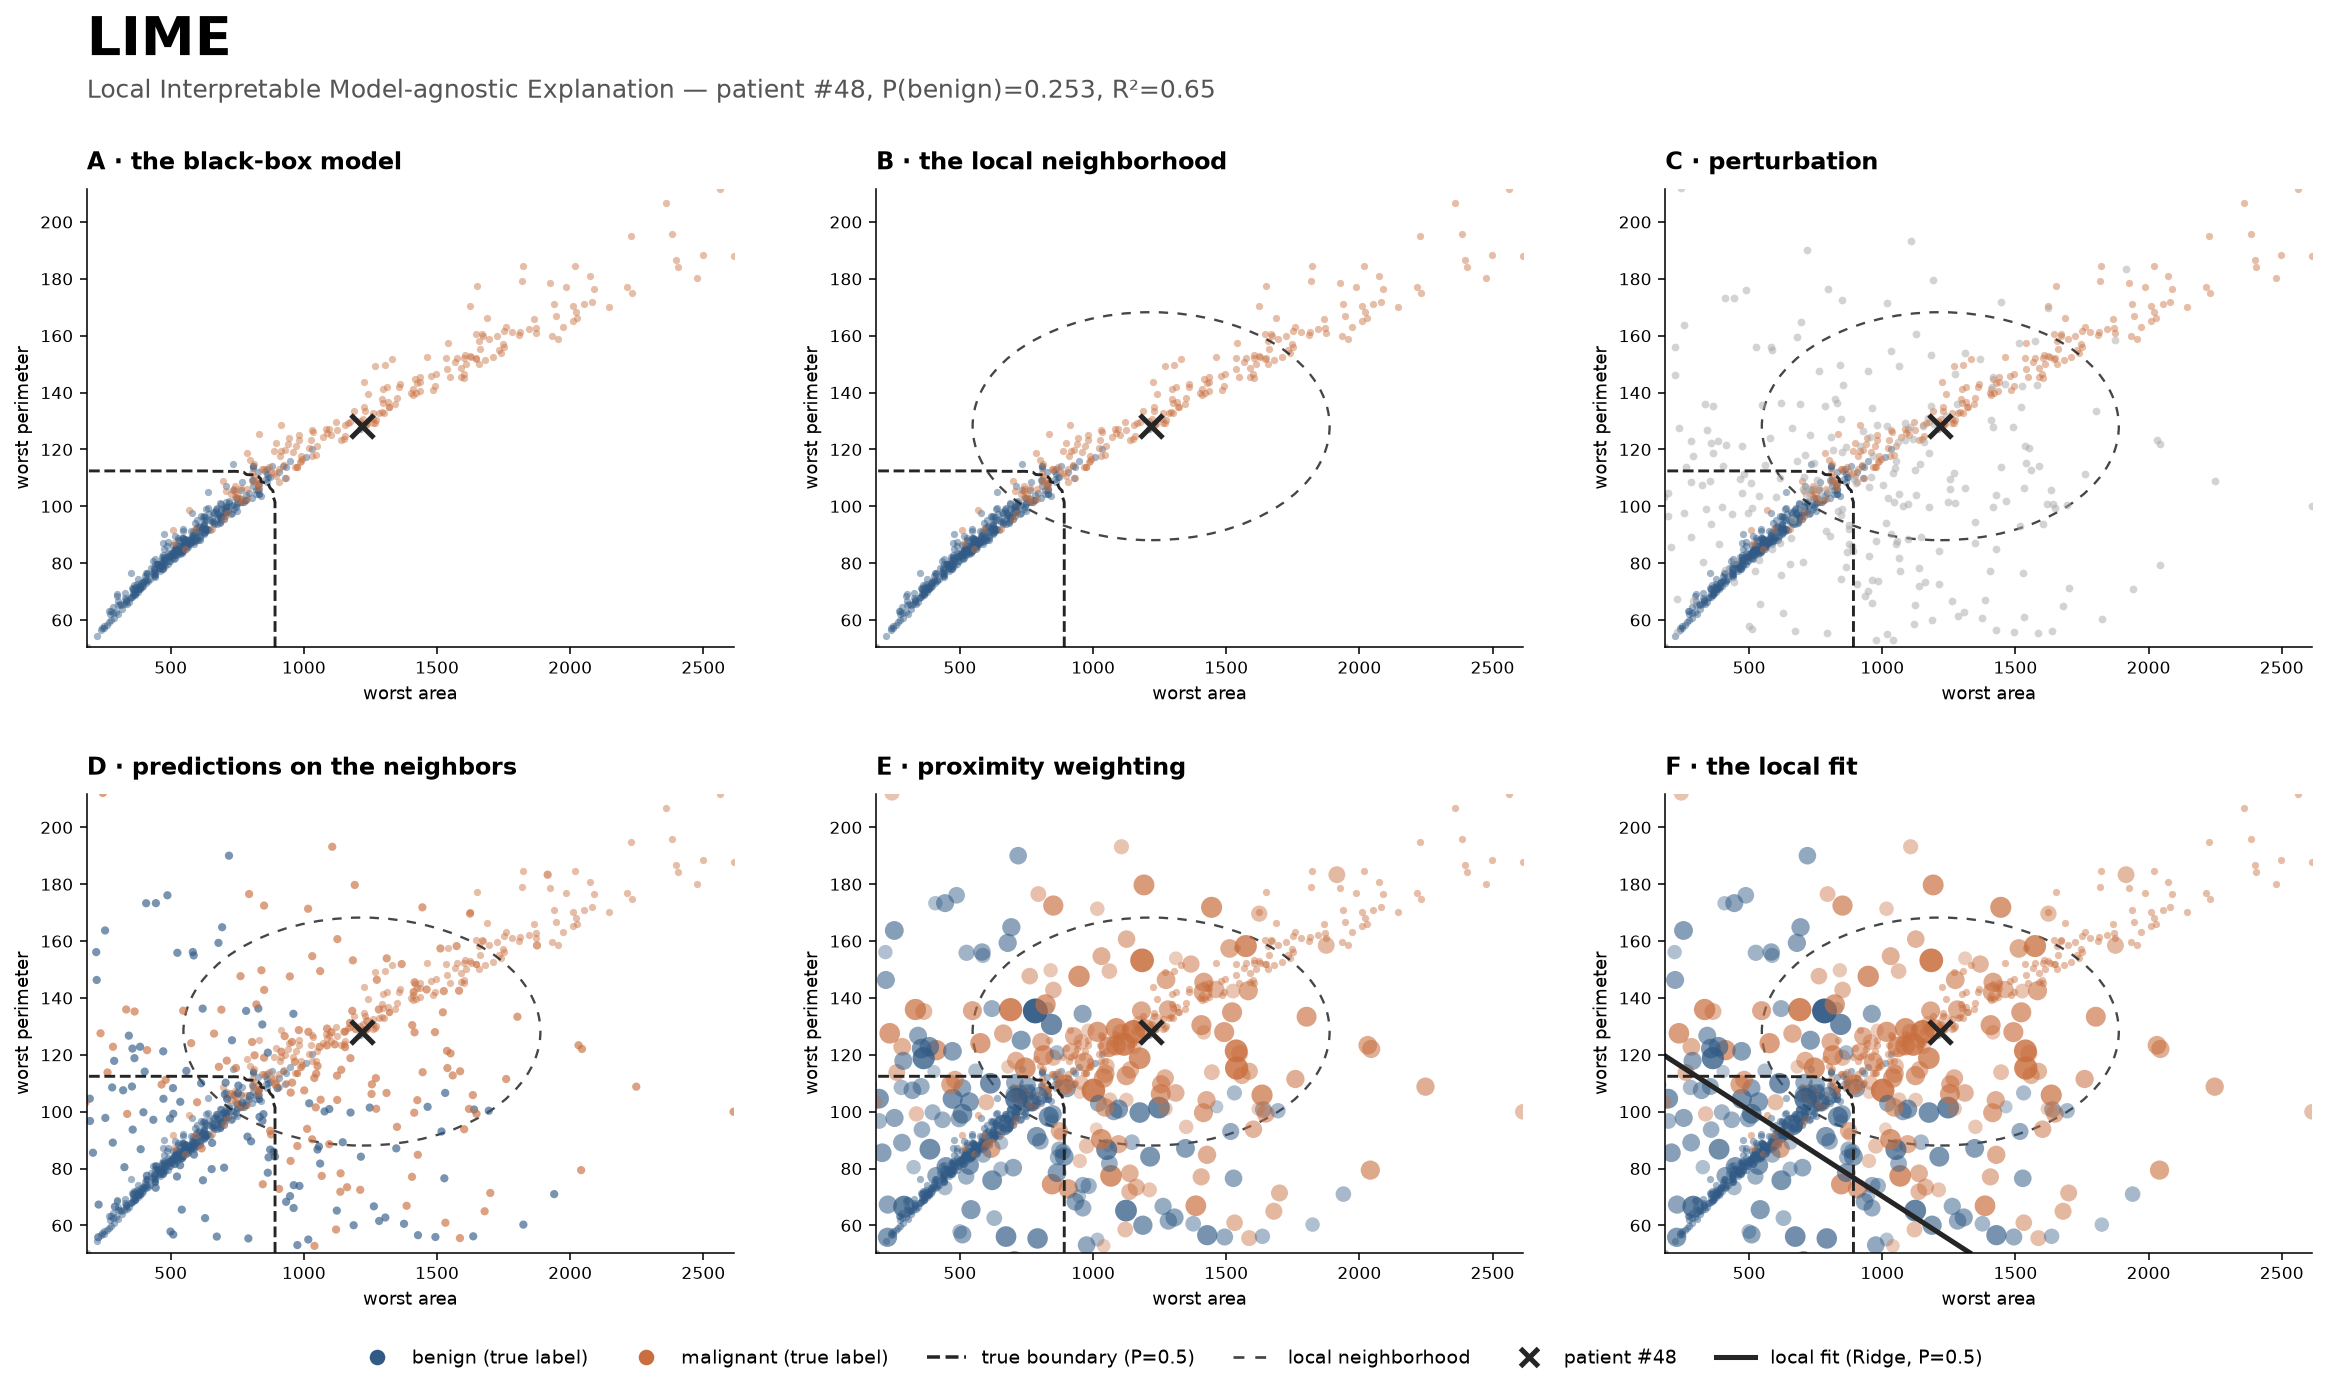

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.subplots_adjust(left=0.045, right=0.98, top=0.86, bottom=0.10, wspace=0.22, hspace=0.32)

panel_titles = [
    "A · the black-box model", "B · the local neighborhood", "C · perturbation",
    "D · predictions on the neighbors", "E · proximity weighting", "F · the local fit",
]
axA, axB, axC, axD, axE, axF = axes.ravel()

for ax, title in zip(axes.ravel(), panel_titles):
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=10)
    ax.set_xlim(grid_x.min(), grid_x.max())
    ax.set_ylim(grid_y.min(), grid_y.max())
    ax.set_xlabel(axis_x_name, fontsize=9.5)
    ax.set_ylabel(axis_y_name, fontsize=9.5)
    ax.tick_params(labelsize=8.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.scatter(X_all[y_all == 1, ix], X_all[y_all == 1, iy], s=14, color=BLUE, alpha=0.45, linewidth=0)
    ax.scatter(X_all[y_all == 0, ix], X_all[y_all == 0, iy], s=14, color=TERRACOTTA, alpha=0.45, linewidth=0)
    ax.contour(GX, GY, PROB_SLICE, levels=[0.5], colors=[DARK], linewidths=1.5, linestyles="--")

# an Ellipse (a Patch) can only belong to 1 axes at a time — each panel
# needs its own instance, the same object cannot be reused
for ax in (axB, axC, axD, axE, axF):
    ax.add_patch(Ellipse(
        (row[ix], row[iy]), width=2.4 * train_std[ix], height=2.4 * train_std[iy],
        fill=False, color=DARK, linewidth=1.2, linestyle=(0, (4, 4)), alpha=0.85))

axC.scatter(Z_vis[:, ix], Z_vis[:, iy], s=16, color=GRAY, alpha=0.5, linewidth=0)
axD.scatter(Z_vis[:, ix], Z_vis[:, iy], s=18, color=neighbor_colors, alpha=0.65, linewidth=0)
for ax in (axE, axF):
    ax.scatter(Z_vis[:, ix], Z_vis[:, iy], s=neighbor_sizes * 0.7, color=neighbor_colors,
               alpha=neighbor_alphas, linewidth=0)

if line_visible:
    y_line, inside = local_line(exp, row, grid_x, grid_y)
    axF.plot(grid_x[inside], y_line[inside], color=DARK, linewidth=2.6)

for ax in (axA, axB, axC, axD, axE, axF):
    ax.scatter(row[ix], row[iy], s=140, marker="x", color=DARK, linewidths=2.6, zorder=20)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=BLUE, markersize=7, label="benign (true label)"),
    plt.Line2D([], [], marker="o", linestyle="", color=TERRACOTTA, markersize=7, label="malignant (true label)"),
    plt.Line2D([], [], color=DARK, linewidth=1.8, linestyle="--", label="true boundary (P=0.5)"),
    plt.Line2D([], [], color=DARK, linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.85, label="local neighborhood"),
    plt.Line2D([], [], marker="x", linestyle="", color=DARK, markersize=9, markeredgewidth=2.6,
               label=f"patient #{instance_idx}"),
    plt.Line2D([], [], color=DARK, linewidth=2.6, label="local fit (Ridge, P=0.5)"),
]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.005))

fig.suptitle("LIME", fontsize=28, fontweight="bold", x=0.045, ha="left", y=0.985)
fig.text(0.045, 0.925,
         f"Local Interpretable Model-agnostic Explanation — patient #{instance_idx}, "
         f"P(benign)={row_proba:.3f}, R²={r2:.2f}",
         fontsize=13, color="#555555", ha="left")

save_figure(fig, "lime_walkthrough_combined")
fig.savefig(os.path.join(FIG_DIR, "lime_walkthrough_combined.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "lime_walkthrough_combined.svg"), bbox_inches="tight")
plt.show()

## When the explanation is NOT reliable

Everything above was the "textbook" case: an explanation with good
fidelity. But that is not guaranteed — and it matters as much as the
mechanism itself. From Molnar,
[*Interpretable Machine Learning*, LIME chapter](https://christophm.github.io/interpretable-ml-book/lime.html):

> "The learned model should be a good approximation of the machine
> learning model predictions locally, but it does not have to be a good
> global approximation. This kind of accuracy is also called **local
> fidelity**."
>
> "The fidelity measure (...) gives us a good idea of how reliable the
> interpretable model is in explaining the black box predictions in the
> neighborhood of the data instance of interest."

In other words: the R² is not a technical detail, it is the answer to
"can I trust this?". Molnar also flags two limitations he calls serious —
**instability** (nearby points can produce very different explanations —
we test this for real in `lime_internals.ipynb`) and the choice of
neighborhood size (there is no standard way to decide it — we use the
package default throughout this walkthrough).

### First, why a #48 does not always exist: the big picture

The 95.1% accuracy is not evenly distributed across patients:

In [13]:
confident = np.abs(proba_test - 0.5) >= 0.3
borderline = np.abs(proba_test - 0.5) < 0.15
print(f"confident cases (P outside [0.2 – 0.8]): {confident.sum()} of {len(proba_test)} "
      f"({confident.sum()/len(proba_test):.0%}) — accuracy: {accuracy_score(y_test[confident], (proba_test[confident]>=0.5).astype(int)):.1%}")
print(f"borderline cases (P within [0.35 – 0.65]): {borderline.sum()} of {len(proba_test)} "
      f"({borderline.sum()/len(proba_test):.0%}) — accuracy: {accuracy_score(y_test[borderline], (proba_test[borderline]>=0.5).astype(int)):.1%}")

confident cases (P outside [0.2 – 0.8]): 127 of 143 (89%) — accuracy: 99.2%
borderline cases (P within [0.35 – 0.65]): 6 of 143 (4%) — accuracy: 66.7%


The global accuracy is carried almost entirely by the confident cases.
Let us look closely at one of the 6 borderline patients: **#88**.

In [14]:
idx_88 = 88
row_88 = X_test[idx_88]
proba_88 = proba_test[idx_88]
pred_88 = class_names[int(proba_88 >= 0.5)]
true_88 = class_names[y_test[idx_88]]
ix88, iy88 = feat_idx["worst area"], feat_idx["worst concave points"]
print(f"patient #{idx_88}: P(benign)={proba_88:.3f}  predicted={pred_88}  true={true_88}"
      + ("  ← the model gets this one WRONG" if pred_88 != true_88 else ""))

exp_88 = explainer.explain_instance(row_88, model.predict_proba, num_features=8, num_samples=5000, labels=(1,))
r2_88 = exp_88.score
point_pred_88 = exp_88.local_pred[0]
print(f"R² (local fidelity): {r2_88:.3f}   (vs {r2:.3f} for patient #{instance_idx})")
print(f"line at the point: {point_pred_88:.4f}  vs real model: {proba_88:.4f}  "
      f"diff={abs(point_pred_88-proba_88):.4f}  (close, here)")

patient #88: P(benign)=0.497  predicted=malignant  true=benign  ← the model gets this one WRONG
R² (local fidelity): 0.390   (vs 0.652 for patient #48)
line at the point: 0.4838  vs real model: 0.4975  diff=0.0137  (close, here)


### Even with well-chosen axes, she sits in a genuine overlap region

Is it only the 30-feature model that "finds" this case complicated, or do
the 2 plot axes already show the same thing on their own?

In [15]:
d2 = np.sqrt(((X_all[:, ix88] - row_88[ix88]) / X_all[:, ix88].std()) ** 2 +
             ((X_all[:, iy88] - row_88[iy88]) / X_all[:, iy88].std()) ** 2)
nearest15 = np.argsort(d2)[1:16]
print(f"15 nearest neighbors of #88 using ONLY worst area / worst concave points "
      f"(ignoring the other 28 features):")
print(f"  share of benign among them: {y_all[nearest15].mean():.0%}  (right in the middle — genuine overlap)")

15 nearest neighbors of #88 using ONLY worst area / worst concave points (ignoring the other 28 features):
  share of benign among them: 47%  (right in the middle — genuine overlap)


She really is in a region where the two classes mix — even in a 2-variable
slice. A curiosity: a logistic regression using only these 2 features
(nothing else) guesses this patient correctly as benign — the simple model
"got it right" here, the 30-feature RandomForest did not. That does not
make the simple model better in general (its accuracy over the whole test
set is much lower, ~92% vs 95%) — only that no model, simple or complex,
is infallible on genuinely ambiguous cases.

### The line holds up near the patient, but it does not know when to stop

In [16]:
coef_map_88 = dict(exp_88.local_exp[1])
weights_88 = {feature_names[f]: w for f, w in exp_88.local_exp[1]}
top_feat_88 = max(weights_88, key=lambda f: abs(weights_88[f]))
i_top_88 = feat_idx[top_feat_88]
print(f"moving only '{top_feat_88}' away from patient #88, holding the other 29 fixed:")
for delta in [0, 1, 2, 4, 8]:
    probe = row_88.copy()
    probe[i_top_88] = row_88[i_top_88] + delta * train_std[i_top_88]
    real = model.predict_proba(probe.reshape(1, -1))[0, 1]
    zs = (probe - train_mean) / train_std
    line_pred = exp_88.intercept[1] + sum(w * zs[j] for j, w in coef_map_88.items())
    warn = "  ← impossible (the line extrapolated outside [0,1])" if not (0 <= line_pred <= 1) else ""
    print(f"  +{delta}σ: real model={real:.3f}   line predicts={line_pred:.3f}{warn}")
print("\nThe real model saturates; the line, being a line, does not — it even "
      "predicts a negative probability. That is what R²≈0.39 is warning about: "
      "trust the DIRECTION of the weights near the patient, not the line far from it.")

moving only 'worst area' away from patient #88, holding the other 29 fixed:
  +0σ: real model=0.497   line predicts=0.484
  +1σ: real model=0.357   line predicts=0.411
  +2σ: real model=0.357   line predicts=0.338
  +4σ: real model=0.357   line predicts=0.192
  +8σ: real model=0.357   line predicts=-0.100  ← impossible (the line extrapolated outside [0,1])

The real model saturates; the line, being a line, does not — it even predicts a negative probability. That is what R²≈0.39 is warning about: trust the DIRECTION of the weights near the patient, not the line far from it.


## Closing

The RandomForest is reliable for most patients (89% of them, with 99.2%
accuracy there) — and for those, LIME delivers an explanation with good
fidelity (as we saw with #48, R²=0.65). But in a small, real slice (4% of
patients, 6 of 143 in the test set), the model genuinely hesitates — and
that is exactly where the explanation also becomes less reliable (R²=0.39
for #88), not by coincidence: local fidelity measures precisely that
frontier between "I can trust this" and "I need a second opinion". LIME's
value is not that it is never wrong — it is that it tells you, case by
case, how much to trust it.